# Early Stopping + Loss History on SJAFFE

Trains five neural-net LDL models on the **SJAFFE** dataset with a uniform
recipe:

- max **2500** epochs (an upper bound — early stopping cuts it short),
- `LDLEarlyStopping(monitor='kl_divergence', patience=50)`, restoring
  best weights when triggered,
- `LossHistory` captures per-epoch training loss and validation KL,
- 80 / 20 train/test split (the test split doubles as the validation set
  for early-stopping signal).

For each model we plot training loss + validation KL on twin axes, then a
combined comparison and a final test-score table.


In [9]:
import importlib
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# force redownload of local moduls

import pyldl.utils
import pyldl.algorithms
importlib.reload(pyldl.utils)
importlib.reload(pyldl.algorithms)


from pyldl.utils import load_dataset, LDLEarlyStopping, LossHistory
from pyldl.algorithms import AA_BP, Duo_LDL, EDL_LDL, BEDL_LDL, SNEFY_LDL, SA_BFGS


## Load SJAFFE

In [45]:
X, D = load_dataset('SBU_3DFE', dir='dataset')
X_train, X_test, D_train, D_test = train_test_split(X, D, test_size=0.2, random_state=0)
X_val, X_test, D_val, D_test = train_test_split(X_test, D_test, test_size=0.5, random_state=0)
print(f'X_train={X_train.shape}  D_train={D_train.shape}')
print(f'X_val  ={X_val.shape}    D_val  ={D_val.shape}')
print(f'X_test ={X_test.shape}   D_test ={D_test.shape}')


X_train=(2000, 243)  D_train=(2000, 6)
X_val  =(250, 243)    D_val  =(250, 6)
X_test =(250, 243)   D_test =(250, 6)


In [46]:
X_train.min(), X_train.max()

(0.00017474969675787915, 0.5725982196089718)

## Training helper

`train_with_history` runs one model with the standard early-stopping +
loss-history callback pair and returns both the trained model and the
captured history.

`AA_BP` gets `AdamW(1e-2)` because its inherited default is
`SGD(1e-3)`, which converges far too slowly to see meaningful behaviour
inside 2500 epochs. The other four models inherit `Adam(1e-3)` from
`BaseAdam` and we leave that alone for an apples-to-apples comparison.


In [47]:
def train_with_history(name, model, kwargs, **fit_kwargs):
    history = LossHistory()
    callbacks = [
        LDLEarlyStopping(monitor='kl_divergence', patience=kwargs.get('patience', 50), minimum=kwargs.get('minimum', 100)),
        history,
    ]
    print(f'--- training {name} ---')
    model.fit(
        X_train, D_train,
        epochs=kwargs.get('max_epochs', 2500), batch_size=kwargs.get('batch_size', 64),
        X_val=X_val, D_val=D_val,
        callbacks=callbacks,
        optimizer=keras.optimizers.AdamW(learning_rate=kwargs.get('learning_rate', 1e-3), weight_decay=kwargs.get('weight_decay', 1e-4)),
        dropout_rate=kwargs.get('dropout_rate', 0.2),
        **fit_kwargs
    )
    n_epochs = len(history.history.get('loss', []))
    print(f'  finished after {n_epochs} epochs')
    return model, history


## Train each model

In [ ]:
results = {}

kwargs = {
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'dropout_rate': 0.2,
        'n_hidden': 32,
        'patience': 20,
        'minimum': 20,
        'max_epochs': 2500,
        'batch_size': 256,
}

results['AA_BP'] = train_with_history(
    'AA_BP', AA_BP(n_hidden=n_hidden), kwargs=kwargs)
results['Duo_LDL']   = train_with_history(
    'Duo_LDL',   Duo_LDL(n_hidden=n_hidden), kwargs=kwargs)
results['EDL_LDL']   = train_with_history(
    'EDL_LDL',   EDL_LDL(n_hidden=n_hidden), kwargs=kwargs)
results['BEDL_LDL']  = train_with_history(
    'BEDL_LDL',  BEDL_LDL(n_hidden=n_hidden), kwargs=kwargs)
results['EDL_LDL_bayes']   = train_with_history(
    'EDL_LDL_bayes',   EDL_LDL(n_hidden=n_hidden), kwargs=kwargs, loss_type='bayes_mse')
results['BEDL_LDL_bayes']  = train_with_history(
    'BEDL_LDL_bayes',  BEDL_LDL(n_hidden=n_hidden), kwargs=kwargs, loss_type='bayes_mse')
results['SNEFY_LDL'] = train_with_history(
    'SNEFY_LDL', SNEFY_LDL(), kwargs=kwargs)


--- training AA_BP ---
  finished after 29 epochs
--- training Duo_LDL ---
  finished after 32 epochs
--- training EDL_LDL ---
  finished after 965 epochs
--- training BEDL_LDL ---


## Per-model loss curves

Training loss (blue, left axis) and validation KL divergence (red, right
axis) on twin axes. Early-stopping fires when the val-KL curve fails to
improve for 50 epochs; the model's final weights are restored to the
best-val-KL epoch.


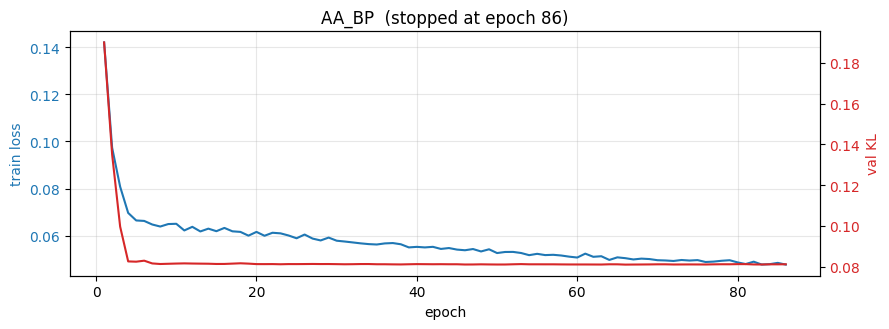

In [51]:
fig, axes = plt.subplots(len(results), 1, figsize=(9, 3.4 * len(results)), squeeze=False)

for ax_row, (name, (_, h)) in zip(axes, results.items()):
    ax = ax_row[0]
    ep = range(1, len(h.history['loss']) + 1)
    ax.plot(ep, h.history['loss'], color='C0', label='train loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('train loss', color='C0')
    ax.tick_params(axis='y', labelcolor='C0')

    ax2 = ax.twinx()
    ax2.plot(ep, h.history['kl_divergence'], color='C3', label='val KL')
    ax2.set_ylabel('val KL', color='C3')
    ax2.tick_params(axis='y', labelcolor='C3')

    ax.set_title(f'{name}  (stopped at epoch {len(ep)})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Validation KL comparison across models

All five val-KL curves on a single axis. Useful for seeing which models
converge faster vs. which reach a lower final KL.


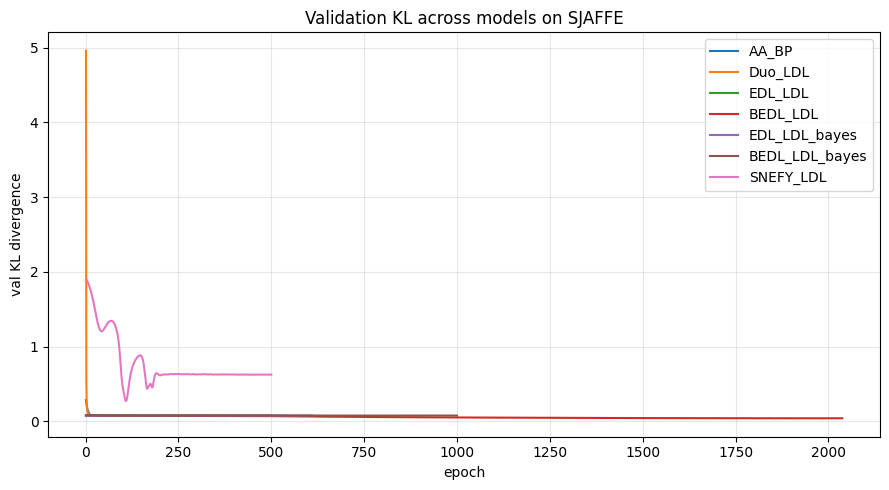

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (_, h) in results.items():
    kl = h.history['kl_divergence']
    ax.plot(range(1, len(kl) + 1), kl, label=name)

ax.set_xlabel('epoch'); ax.set_ylabel('val KL divergence')
ax.set_title('Validation KL across models on SJAFFE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Final test-set scores

Computed on `X_test` / `D_test` after early-stopping has restored each
model to its best-val-KL weights.


In [21]:
METRICS = ['chebyshev', 'clark', 'canberra', 'kl_divergence', 'cosine', 'intersection']

rows = []
for name, (model, h) in results.items():
    s = model.score(X_test, D_test, metrics=METRICS, return_dict=True)
    rows.append({
        'model': name,
        'epochs_run': len(h.history.get('loss', [])),
        **{k: float(v) for k, v in s.items()},
    })

scores_df = pd.DataFrame(rows).set_index('model')
scores_df


,epochs_run,chebyshev,clark,canberra,kl_divergence,cosine,intersection
model,,,,,,,
AA_BP,500,0.145243,0.472253,1.013395,0.096173,0.908250,0.822779
Duo_LDL,500,0.146355,0.473862,1.016976,0.099573,0.905760,0.821999
EDL_LDL,540,0.148274,0.477676,1.024392,0.103000,0.902857,0.820541
BEDL_LDL,2037,0.103953,0.337564,0.721555,0.046351,0.954288,0.874128
EDL_LDL_bayes,610,0.145349,0.471771,1.010938,0.095148,0.909024,0.823244
BEDL_LDL_bayes,1000,0.145253,0.472265,1.011443,0.095394,0.908806,0.823112
SNEFY_LDL,500,0.196204,0.862710,1.738893,0.270555,0.812260,0.724607


In [16]:
sa_bfgs_mod = SA_BFGS()
sa_bfgs_mod.fit(X_train, D_train)
scores = sa_bfgs_mod.score(X_test, D_test, return_dict=True)
print(f'--- {sa_bfgs_mod.__class__.__name__} ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- SA_BFGS ---
chebyshev: 0.3401
clark: 2.4391
canberra: 6.7471
kl_divergence: 0.8357
cosine: 0.7150
intersection: 0.5386
